In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
import joblib

In [2]:
#Load dataset
dataset = pd.read_csv(r"C:\Users\murja\Desktop\AI_ML001\3Logy-NDI-AI-ML-Crash\datasets\telecom_churn_dataset (1).csv")
dataset.head()

,CustomerID,Gender,SeniorCitizen,TenureMonths,MonthlyCharges,Contract,InternetService,TechSupport,Churn
0,CUST1000,Male,0,45,24.24,Month-to-month,Fiber optic,No,No
1,CUST1001,Female,1,57,108.41,Month-to-month,DSL,No,No
2,CUST1002,Female,0,54,90.96,Month-to-month,DSL,Yes,Yes
3,CUST1003,Male,1,10,37.31,Month-to-month,DSL,No,Yes
4,CUST1004,Male,1,60,29.17,One year,DSL,Yes,No


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       300 non-null    str    
 1   Gender           300 non-null    str    
 2   SeniorCitizen    300 non-null    int64  
 3   TenureMonths     300 non-null    int64  
 4   MonthlyCharges   300 non-null    float64
 5   Contract         300 non-null    str    
 6   InternetService  300 non-null    str    
 7   TechSupport      300 non-null    str    
 8   Churn            300 non-null    str    
dtypes: float64(1), int64(2), str(6)
memory usage: 21.2 KB


In [4]:
dataset.head()

,CustomerID,Gender,SeniorCitizen,TenureMonths,MonthlyCharges,Contract,InternetService,TechSupport,Churn
0,CUST1000,Male,0,45,24.24,Month-to-month,Fiber optic,No,No
1,CUST1001,Female,1,57,108.41,Month-to-month,DSL,No,No
2,CUST1002,Female,0,54,90.96,Month-to-month,DSL,Yes,Yes
3,CUST1003,Male,1,10,37.31,Month-to-month,DSL,No,Yes
4,CUST1004,Male,1,60,29.17,One year,DSL,Yes,No


In [5]:
dataset.Churn.value_counts()

Churn
No     155
Yes    145
Name: count, dtype: int64

In [6]:
dataset.Churn.value_counts(normalize=True)

Churn
No     0.516667
Yes    0.483333
Name: proportion, dtype: float64

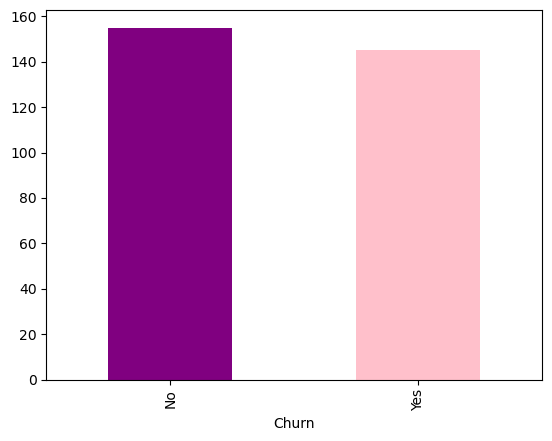

In [7]:
dataset.Churn.value_counts().plot(kind="bar", color=["purple", "pink"]);

In [8]:
dataset.describe()

,SeniorCitizen,TenureMonths,MonthlyCharges
count,300.000000,300.000000,300.000000
mean,0.503333,37.550000,69.920400
std,0.500824,21.395171,28.724659
min,0.000000,1.000000,20.120000
25%,0.000000,18.000000,47.997500
50%,1.000000,39.000000,69.550000
75%,1.000000,56.000000,94.452500
max,1.000000,72.000000,119.870000


In [9]:
dataset.Gender.value_counts()

Gender
Male      155
Female    145
Name: count, dtype: int64

In [10]:
pd.crosstab(index=dataset.Churn, columns=dataset.Gender)

Gender,Female,Male
Churn,,
No,78,77
Yes,67,78


In [11]:
corr_matrix = dataset.corr(numeric_only=True)
corr_matrix

,SeniorCitizen,TenureMonths,MonthlyCharges
SeniorCitizen,1.000000,-0.017807,0.055654
TenureMonths,-0.017807,1.000000,0.030635
MonthlyCharges,0.055654,0.030635,1.000000


In [12]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

In [13]:
X = dataset.drop(["Churn", "CustomerID"], axis=1)
y = dataset["Churn"]

In [14]:
X = pd.get_dummies(X, drop_first=True)

In [15]:
dataset.head(10)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size=0.25) # by default train_test_split uses 25% of the data for the test set

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((225, 9), (75, 9), (225,), (75,))

In [16]:
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
from sklearn.metrics import accuracy_score, classification_report

In [18]:
# --- LOOP 2: EVALUATE ---
y_pred = clf.predict(X_test)
print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nModel Report:\n", classification_report(y_test, y_pred))

Final Accuracy: 57.33%

Model Report:
               precision    recall  f1-score   support

          No       0.56      0.56      0.56        36
         Yes       0.59      0.59      0.59        39

    accuracy                           0.57        75
   macro avg       0.57      0.57      0.57        75
weighted avg       0.57      0.57      0.57        75



In [19]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [20]:
X_test.head()

,SeniorCitizen,TenureMonths,MonthlyCharges,Gender_Male,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,TechSupport_Yes
200,0,1,60.14,True,False,False,False,False,False
29,1,27,61.18,True,False,True,False,False,True
106,0,1,49.21,False,True,False,False,False,True
196,0,70,20.45,True,True,False,True,False,False
268,1,33,85.29,False,False,False,True,False,False


In [21]:
train_acc = clf.score(X=X_train, y=y_train)
print(f"The model's accuracy on the training dataset is: {train_acc*100}%")

The model's accuracy on the training dataset is: 100.0%


In [22]:
def predict(input_data):
    input_scaled = scaler.transform([input_data])
    return model.predict(input_scaled)


In [23]:
test_acc = clf.score(X=X_test, y=y_test)
print(f"The model's accuracy on the testing dataset is: {test_acc*100:.2f}%")

The model's accuracy on the testing dataset is: 57.33%


In [24]:
# Another way to do it with GridSearchCV...
np.random.seed(42)
from sklearn.model_selection import GridSearchCV

# Define the parameters to search over in dictionary form 
# (these can be any of your target model's hyperparameters) 
param_grid = {'n_estimators': [i for i in range(100, 200, 10)]}

# Setup the grid search
grid = GridSearchCV(estimator=RandomForestClassifier(),
                    param_grid=param_grid,
                    cv=5,
                    verbose=1) 

# Fit the grid search to the data
grid.fit(X, y)

# Find the best parameters
print(f"The best parameter values are: {grid.best_params_}")
print(f"With a score of: {grid.best_score_*100:.2f}%")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best parameter values are: {'n_estimators': 120}
With a score of: 61.67%


In [25]:
# Expanded grid search
param_grid = {
    'n_estimators': [150, 170, 190],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None] # Crucial for churn data
}

grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                    param_grid=param_grid,
                    cv=5, 
                    scoring='accuracy',
                    n_jobs=-1,
                    verbose=1)

grid.fit(X, y)
print(f"New Best Score: {grid.best_score_*100:.2f}%")
print(f"Best Params: {grid.best_params_}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
New Best Score: 62.67%
Best Params: {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 150}


In [26]:
# #Minimal check
# from joblib import dump, load
import joblib

# Save a model using joblib
# dump(model, "random_forest_model_1.joblib")
joblib.dump(grid, "random_forest_model_1.joblib")

['random_forest_model_1.joblib']

In [27]:
# Load a saved joblib model
loaded_joblib_model = joblib.load("random_forest_model_1.joblib")
print(f"Loaded joblib model prediction score: {loaded_joblib_model.score(X_test, y_test) * 100:.2f}%")

Loaded joblib model prediction score: 89.33%


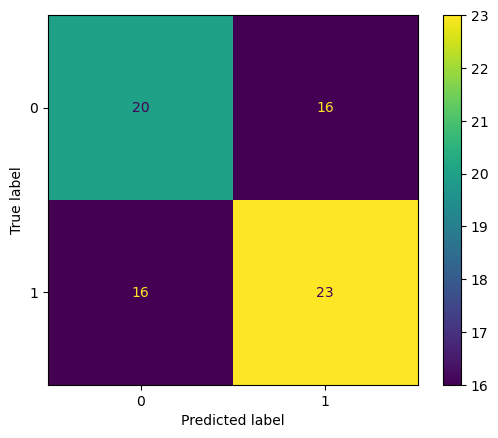

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make predictions first
y_pred = clf.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

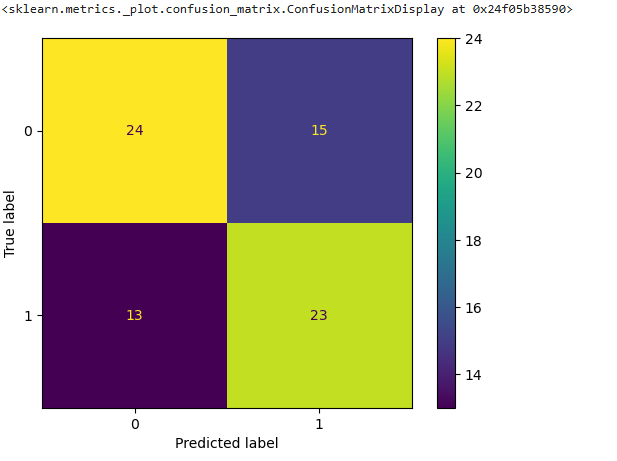

In [29]:
from IPython.display import Image, display
from IPython.display import Image, display

# confusion matrix image from last test to be compared with the latest confusion matrix
display(Image(filename=r'C:\Users\murja\Desktop\AI_ML001\3Logy-NDI-AI-ML-Crash\images\Screenshot 2026-04-15 162854.png'))
